## Demo for GMM component elongation plot
(just for the book)

In [2]:
import pandas as pd
import joblib
import numpy as np

#import dask.dataframe as ddf

import sample_group_stats as sgstat
from sample_group import SG
import extools as ex

import databox as db
import syn_tree

OK -- read the ontology db (19571, 4)
Restored 303734 tags and 191240 tokens. Run update_corpus_tagdata() to update.
-- loaded the skipgram model tank/fasttext_8.model --


In [3]:
grid=sgstat.GMMScore(SG('Bird#class'),'adaptation_comment')

My URI: Bird#class
My path: data/Bird__class/
My taxons: (226) ['Barn_Owl#species', 'Buff-necked_Ibis#species', 'Common_Crane#species'] ...
Loaded data/Bird__class//pair_df.pkl
ica_tf.pkl restored
=== get_tokendict Restored SG token dictionary data/Bird__class//token_dict.pkl
==make_tokenfeat_df==
==make_tokenfeat_df done==
restored data/Bird__class//gmm_dict.pkl


In [75]:
comp_id = 4

comp_ex_feat, feats_hilite, my_x, feats_cxy, v, w = grid.gmm_comp_eigvec(comp_id,max_F=10)
all_x = grid.idata[grid.gmm.predict(grid.idata) == comp_id]
feats_hilite

,0,1,2,3,4,5,6,7
arcpath_lemma,,,,,,,,
nmod>case> in,-0.385864,-0.447932,-0.667476,0.077750,0.075480,-0.022668,-0.503786,-0.124172
obl<nsubj> ...,0.410518,-0.278795,0.203257,0.119690,0.312428,0.182927,-0.283243,-0.178769
case> ...,-0.420326,-0.439809,0.273446,-0.382443,0.023402,0.299731,0.208109,-0.264330
nsubj<advmod> ...,-0.425354,0.237991,0.354644,0.108540,0.052351,0.180910,0.115665,-0.058125
case> of,-0.477800,-0.481510,0.197526,-0.359105,0.027677,0.326682,0.164817,-0.281690
nsubj< include,-0.520332,-0.261692,-0.522421,0.070859,-0.083238,0.135534,-0.265554,-0.073351
nsubj< owl,-0.572571,0.184998,-0.373599,0.184920,-0.013087,0.279125,-0.051138,-0.039391
conj> owl,0.610846,-0.087681,0.263782,0.116974,0.501670,0.063862,-0.189803,0.036144
conj> ...,0.612391,-0.111519,0.257683,0.149778,0.554129,0.136615,-0.163375,0.124021


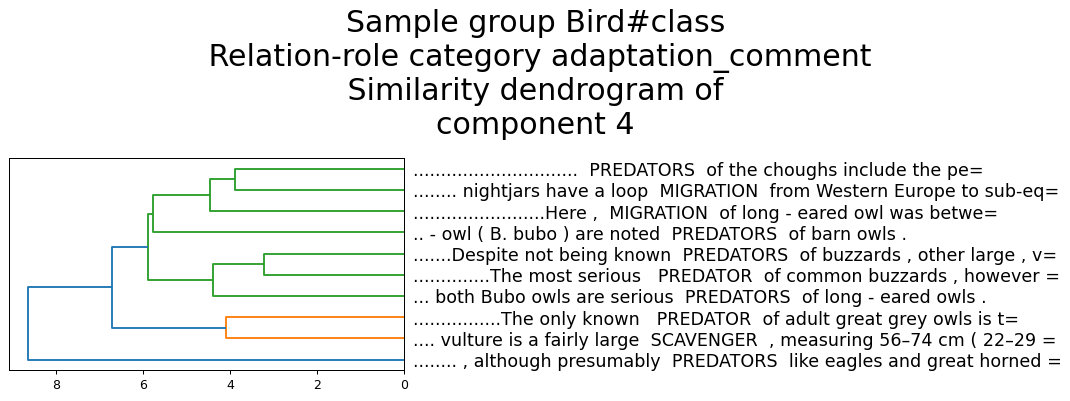

In [76]:
grid.make_dendrogram(comp_id,topN=len(feats_hilite))

In [80]:
#grid.make_dendrogram(0,topN=len(feats_hilite))

In [77]:
comp_ex_feat.sample(5,replace=True).drop_duplicates().sort_values('elongation_x')
#comp_ex_feat.feat.value_counts()

,token,token_form,concept_uri,arcpath,lemma,upos,widx,feat,elongation_x,elongation_y
10,Ame-86f0_149_predators-12,predators,Predation#adaptation,nmod>case>,in,ADP,15,nmod>case> in,-0.385864,-0.447932
14,And-dffe_117_scavengers-37,scavengers,Scavenger#adaptation,nmod>case>,in,ADP,38,nmod>case> in,-0.385864,-0.447932
1,Lon-b0af_538_predators-2,predators,Predation#adaptation,nmod>case>,of,ADP,3,nmod>case> of,-0.360489,-0.456225
26,Com-f222_480_predator-6,predator,Predation#adaptation,conj>,kestrel,NOUN,37,conj> ...,0.565397,-0.114122
11,Puf-816d_10_migrations-21,migrations,Animal_migration#adaptation,conj>,more,ADJ,26,conj> ...,0.639634,-0.108855


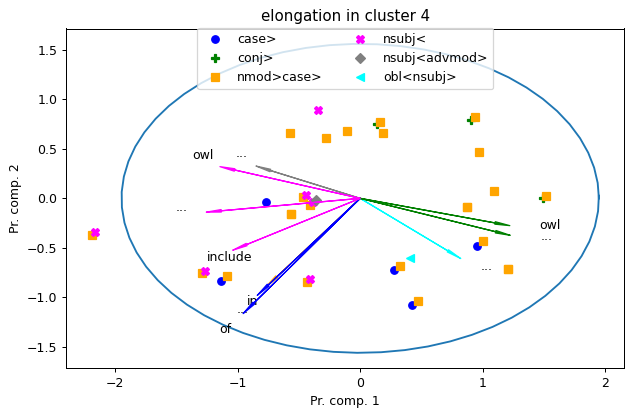

In [78]:
x_shift=all_x-grid.gmm.means_[comp_id]
x_rot = np.matmul(x_shift,w.T)


from matplotlib import figure, pyplot as plt

fig = figure.Figure(figsize=(8,5),dpi=90)
fig.tight_layout(pad=5.0)

axs = fig.subplots(1,1,sharey=False)
ax = axs

legends = []

shift= -0.025
markers = 'oPsXD<>^vH'
colors = ['blue','green','orange','magenta','gray','cyan','maroon','brown','pink','black']
apcolors = {}
i = 0

for ap,df in comp_ex_feat.groupby('arcpath'):
    x_rot_ap = x_rot.loc[df.token]
    x=np.array(x_rot_ap)
    marker=markers[i%10]
    apcolor=colors[i%10]
    ax.plot(x[:,0]+shift,x[:,1]+shift,marker,color=apcolor)
    legends.append(ap)
    apcolors[ap]=apcolor
    shift+=0.025
    i+=1

x_rot_b = x_rot[~x_rot.index.isin(my_x.index)]
if len(x_rot_b):
    x=np.array(x_rot_b)
    ax.plot(x[:,0],x[:,1],'r.')
    legends.append('other')

    
#ax.plot(np.array(x_rot_b)[:,0],np.array(x_rot_b)[:,1],'.')

#ax.text(np.array(x_rot)[3,0],np.array(x_rot)[3,1],'  Yay I\'m\n  free')

ax.set_xlabel("Pr. comp. 1")
ax.set_ylabel("Pr. comp. 2")


aa=np.arange(0,6.4,.1)
ax.plot(np.cos(aa)*v[0]*1.4,np.sin(aa)*v[1]*1.4)

feat_arr = np.array(feats_hilite)


for fi in range(len(feats_hilite)):
    x,y=feat_arr[fi,0:2]*2
    ap=feats_hilite.index[fi].split(' ')[0]
    flemma=feats_hilite.index[fi].split(' ')[1]
    
   
    acolor = apcolors[ap] if ap in apcolors.keys() else 'gray'
    ax.annotate('',(x,y-(fi%5)*0.05),xytext=(0,0),arrowprops={'width':0.02,'headwidth':2,'color':acolor})
    x,y=x*1.2,y*1.2
    ax.text(x,y-(fi%5)*0.05,flemma,fontsize=10)
    ax.plot(x*1.2,y,' ')

ax.plot(0,1.2,' ')


#ax.set_xticks(np.arange(0,2.5,.5))

ax.set_title("elongation in cluster %d" % comp_id)
ax.legend(legends,loc='upper center', bbox_to_anchor=(0.5, 1.02),
          ncol=2, fancybox=True)

fig

In [62]:
# Highlighted features in PC space
feats_hilite

,0,1,2,3,4,5,6,7
arcpath_lemma,,,,,,,,
nmod:poss> ...,0.385862,0.187975,-0.071628,0.157483,0.025145,-0.172114,-0.012339,-0.121174
cc> or,0.401883,0.073767,0.240811,-0.075684,0.061822,-0.180985,-0.472448,-0.361599
obj<obl>case> to,0.404226,0.053285,0.231256,0.340974,0.169998,0.045561,-0.231790,-0.079799
compound>compound> ...,0.406122,0.313664,0.008571,0.215495,0.138575,-0.197141,0.295823,0.126756
nmod:poss> they,0.409312,0.124054,0.008460,0.092207,0.111770,-0.104824,-0.059982,-0.046182
obl< find,-0.463873,0.072624,-0.077293,0.041174,0.085950,-0.022098,0.103138,-0.083082
det> ...,-0.495265,-0.012713,-0.039257,0.069996,0.017273,0.319730,-0.469412,-0.331464
det> a,-0.514618,-0.026697,0.008978,0.104872,0.046812,0.327300,-0.498919,-0.312069
amod< song,0.516121,0.095092,0.094644,0.303996,0.121956,0.306352,-0.246295,0.029412


In [52]:
# Look for example tokens

comp_ex_feat.sort_values('feat')[comp_ex_feat.columns[:-4]]

,token,token_form,concept_uri,arcpath,lemma,upos
0,Com-f222_477_predators-5,predators,Predation#adaptation,case>,despite,ADP
12,And-dffe_117_scavengers-37,scavengers,Scavenger#adaptation,case>,among,ADP
3,Sno-0a8f_478_predators-21,predators,Predation#adaptation,case>,of,ADP
8,Mer-5a4a_101_predators-15,predators,Predation#adaptation,case>,of,ADP
3,Lon-b0af_532_predators-8,predators,Predation#adaptation,case>,of,ADP
26,Com-f222_480_predator-6,predator,Predation#adaptation,conj>,kestrel,NOUN
11,Puf-816d_10_migrations-21,migrations,Animal_migration#adaptation,conj>,more,ADJ
13,Com-f222_468_predator-4,predator,Predation#adaptation,conj>,owl,NOUN
14,Bla-e03a_57_scavenger-8,scavenger,Scavenger#adaptation,nmod>case>,with,ADP
9,Eur-24a9_82_migration-12,migration,Animal_migration#adaptation,nmod>case>,from,ADP


In [63]:
#Gre-e288_39_Mountains-15
#Bat-2d5b_362_social-26

# Bird ada-com cluster 0: modifier-caused elongation (amod>)

# Gra-9199_91_predators-4 - The most **significant** [predators] of the gray mouse lemur are the Madagascar owl
# Lon-b0af_523_predators-7 - most **serious** [predators] tend to be the Eurasian eagle - owl
# And-dffe_117_scavengers-11 - several **mammalian** carnivorous [scavengers] such as foxes may sometimes track Cathartes vultures

# Bird ada-com cluster 4: syntactic role-based elongation (conj>, nsubj<, case>)

# Com-f222_468_predator-4 - The most serious [predator] of common buzzards ... is the **owl** (conj>)
# Cho-a88d_87_Predators-1 - [Predators] of the choughs **include** (nsubj<) the peregrine falcon, golden eagle
# Sno-0a8f_478_predators-21 - the number **of** (case>) [predators] with which the snowy owls are obligated to share prey

# Bird ada-com cluster 2: expressional elongation (det>, amod>)



In [55]:
ex.pretty_token('Sno-0a8f_478_predators-21').ctx

['Alaska , Scandinavia and central Russia , the number of',
 '[predators]',
 'with which the snowy owls are obligated to share prey']

In [14]:
syn_tree.make_syn_tree(db.token_sent('Eur-3ec7_370_territorial-11'))


returned value: 0


'plots/syntrees/tree_5023d31bc9cb1972fc50cf752f843af6.png'

Own notes:

  - Compounds are an interesting theme here, like hibernation site, or colonial organism.
    They might be a clue of a adaptation term usage pattern.
    
    Bat-2d5b_358_hibernation-8 ("hibernation site")
    Col-e01a_35_colonial-5	 ("colonial organism")
    
  - 
 
 
  
  


In [15]:
sgstat.explain_arcpath('compound>amod>',grid.sg,20)

... by " ant - **FOLLOWING** "    BIRDS    such as antbirds and woodcree=
...... the **EXTANT** families TROCHILIDAE  hummingbirds ) , Hemiprocnid=
............A **THIRD** - year     BIRD    will also exhibit a small zon=
..It is a **COASTAL** breeding     BIRD    around the north Pacific and =
....... garden and countryside    BIRDS    have beaks specialised for ea=
.................**OLD** World   PIGEONS   are natives of Europe , Asia =
......This **SMALL** passerine     BIRD    is found in short dense veget=
................**GREAT** grey     OWL     : Threats .                   
................**GREAT** grey     OWL     : Habitat .                   
................**GREAT** grey     OWL     : Range .                     
. **FRESH** - and salt - water   WETLANDS  , including parks , small pon=
............**SOUTHERN** storm   PETRELS    Oceanitidae ) are found in a=
....... trans - **EQUATORIAL**  MIGRATIONS , including the Wilson 's sto=
 are long or **SHORT** - range  MIGRAT

[('Ant-938d_372_birds-22',
  '... by " ant - **FOLLOWING** "    BIRDS    such as antbirds and woodcree='),
 ('Apo-3156_2_Trochilidae-13',
  '...... the **EXTANT** families TROCHILIDAE  hummingbirds ) , Hemiprocnid='),
 ('Bla-8d51_40_bird-5',
  '............A **THIRD** - year     BIRD    will also exhibit a small zon='),
 ('Bla-8d51_49_bird-6',
  '..It is a **COASTAL** breeding     BIRD    around the north Pacific and ='),
 ('Carbfda_4_birds-6',
  '....... garden and countryside    BIRDS    have beaks specialised for ea='),
 ('Colcf39_1_pigeons-3',
  '.................**OLD** World   PIGEONS   are natives of Europe , Asia ='),
 ('Com-124c_5_bird-4',
  '......This **SMALL** passerine     BIRD    is found in short dense veget='),
 ('Gre-e288_98_owl-3',
  '................**GREAT** grey     OWL     : Threats .                   '),
 ('Gre-e288_27_owl-3',
  '................**GREAT** grey     OWL     : Habitat .                   '),
 ('Gre-e288_31_owl-3',
  '................**GREAT** grey 

In [16]:
import importlib
importlib.reload(sgstat)

<module 'sample_group_stats' from '/home/seppo/work/wildlife-ml/notes/sample_group_stats.py'>